<a href="https://colab.research.google.com/github/hilya-23/cnn-apel/blob/main/dataset_apel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
DATASET_DIR = "/content/drive/MyDrive/APPLE_DISEASE_DATASET"

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_DIR = "/content/drive/MyDrive/APPLE_DISEASE_DATASET"

print(DATASET_DIR)

/content/drive/MyDrive/APPLE_DISEASE_DATASET


In [5]:
import os

DATASET_DIR = "/content/drive/MyDrive/APPLE_DISEASE_DATASET"

classes = os.listdir(DATASET_DIR)

print("Kelas dalam dataset:")
for class_name in classes:
    print("-", class_name)

Kelas dalam dataset:
- APPLE ROT LEAVES
- LEAF BLOTCH
- SCAB LEAVES
- HEALTHY LEAVES


In [6]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

total_images = 0

for class_name in classes:
    class_path = os.path.join(DATASET_DIR, class_name)

    if os.path.isdir(class_path):
        count = sum(
            1 for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        )

        print(f"{class_name}: {count} gambar")
        total_images += count

print("\nTotal gambar:", total_images)

APPLE ROT LEAVES: 103 gambar
LEAF BLOTCH: 111 gambar
SCAB LEAVES: 159 gambar
HEALTHY LEAVES: 46 gambar

Total gambar: 419


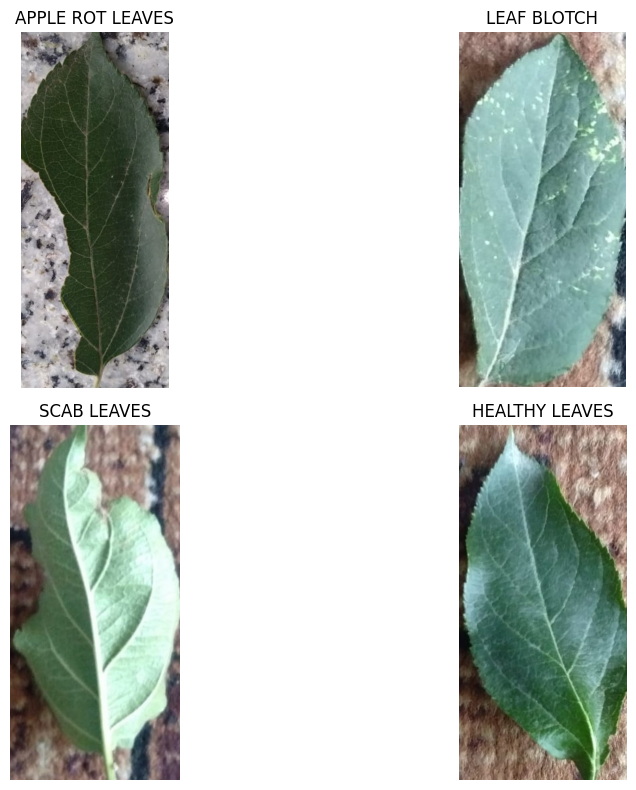

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(DATASET_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import os
import shutil
import random

# Folder hasil split khusus dataset Rice
SPLIT_DIR = "/content/apel_cnn_split"

# Hapus split lama jika sebelumnya pernah dibuat
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Buat folder train, val, test
for split in ["train", "val", "test"]:
    for class_name in classes:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, class_name),
            exist_ok=True
        )

# Seed agar pembagian data dapat direproduksi
random.seed(42)

# Pembagian data
for class_name in classes:
    class_path = os.path.join(DATASET_DIR, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    random.shuffle(image_files)

    total = len(image_files)

    train_count = int(0.8 * total)
    val_count = int(0.1 * total)

    train_files = image_files[:train_count]
    val_files = image_files[train_count:train_count + val_count]
    test_files = image_files[train_count + val_count:]

    # Copy ke train
    for file in train_files:
        shutil.copy2(
            os.path.join(class_path, file),
            os.path.join(SPLIT_DIR, "train", class_name, file)
        )

    # Copy ke validation
    for file in val_files:
        shutil.copy2(
            os.path.join(class_path, file),
            os.path.join(SPLIT_DIR, "val", class_name, file)
        )

    # Copy ke test
    for file in test_files:
        shutil.copy2(
            os.path.join(class_path, file),
            os.path.join(SPLIT_DIR, "test", class_name, file)
        )

print("Split dataset Rice selesai.")
print("Lokasi:", SPLIT_DIR)

Split dataset Rice selesai.
Lokasi: /content/apel_cnn_split


In [9]:
import os

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    print("-" * 30)

    total_split = 0

    for class_name in classes:
        class_path = os.path.join(SPLIT_DIR, split, class_name)

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(image_extensions)
        ])

        print(f"{class_name}: {count}")
        total_split += count

    print(f"Total {split}: {total_split}")


TRAIN
------------------------------
APPLE ROT LEAVES: 82
LEAF BLOTCH: 88
SCAB LEAVES: 127
HEALTHY LEAVES: 36
Total train: 333

VAL
------------------------------
APPLE ROT LEAVES: 10
LEAF BLOTCH: 11
SCAB LEAVES: 15
HEALTHY LEAVES: 4
Total val: 40

TEST
------------------------------
APPLE ROT LEAVES: 11
LEAF BLOTCH: 12
SCAB LEAVES: 17
HEALTHY LEAVES: 6
Total test: 46


**PRE-PROCESSING**

In [10]:
import torch
from torchvision import transforms

IMG_SIZE = 224

# Preprocessing untuk data training
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Preprocessing untuk validation dan test
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Preprocessing berhasil dibuat.")
print("Ukuran gambar:", IMG_SIZE, "x", IMG_SIZE)

Preprocessing berhasil dibuat.
Ukuran gambar: 224 x 224


**MEMBUAT DATA SET OBJEK**

In [11]:
from torchvision import datasets
import os

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Jumlah data train :", len(train_dataset))
print("Jumlah data val   :", len(val_dataset))
print("Jumlah data test  :", len(test_dataset))

print("\nNama kelas:")
print(train_dataset.classes)

print("\nMapping kelas:")
print(train_dataset.class_to_idx)

Jumlah data train : 333
Jumlah data val   : 40
Jumlah data test  : 46

Nama kelas:
['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']

Mapping kelas:
{'APPLE ROT LEAVES': 0, 'HEALTHY LEAVES': 1, 'LEAF BLOTCH': 2, 'SCAB LEAVES': 3}


**DATA LOADER**

In [12]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoader berhasil dibuat.")
print("Batch size:", BATCH_SIZE)

DataLoader berhasil dibuat.
Batch size: 16


In [13]:
images, labels = next(iter(train_loader))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)
print("Label contoh :", labels)

Shape images : torch.Size([16, 3, 224, 224])
Shape labels : torch.Size([16])
Label contoh : tensor([3, 0, 0, 1, 2, 3, 0, 0, 3, 2, 0, 2, 0, 2, 3, 0])


**SKENARIO 1-TRANSFER LEARNING**

In [14]:
import torch
import torch.nn as nn
from torchvision import models

# Menentukan device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device yang digunakan:", device)

# Memuat ResNet50 pretrained ImageNet
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Membekukan seluruh layer ResNet50
for param in model.parameters():
    param.requires_grad = False

# Menyesuaikan output dengan jumlah kelas
num_classes = len(train_dataset.classes)
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, num_classes)

# Memindahkan model ke device
model = model.to(device)

print("Jumlah kelas:", num_classes)
print("Kelas:", train_dataset.classes)
print("Model ResNet50 siap.")

Device yang digunakan: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


Jumlah kelas: 4
Kelas: ['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']
Model ResNet50 siap.


**Loss Function & Optimizer**

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("\nLoss function :", criterion)
print("Optimizer     :", optimizer)


Loss function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [16]:
print("SPLIT_DIR      :", "ADA" if "SPLIT_DIR" in globals() else "TIDAK ADA")
print("train_dataset  :", "ADA" if "train_dataset" in globals() else "TIDAK ADA")
print("val_dataset    :", "ADA" if "val_dataset" in globals() else "TIDAK ADA")
print("test_dataset   :", "ADA" if "test_dataset" in globals() else "TIDAK ADA")
print("train_transform:", "ADA" if "train_transform" in globals() else "TIDAK ADA")
print("model          :", "ADA" if "model" in globals() else "TIDAK ADA")
print("criterion      :", "ADA" if "criterion" in globals() else "TIDAK ADA")
print("optimizer      :", "ADA" if "optimizer" in globals() else "TIDAK ADA")
print("train_model    :", "ADA" if "train_model" in globals() else "TIDAK ADA")

SPLIT_DIR      : ADA
train_dataset  : ADA
val_dataset    : ADA
test_dataset   : ADA
train_transform: ADA
model          : ADA
criterion      : ADA
optimizer      : ADA
train_model    : TIDAK ADA


In [17]:
import os

SPLIT_DIR = "/content/apple_cnn_split"

print("SPLIT_DIR:", SPLIT_DIR)
print("Folder tersedia:", os.path.exists(SPLIT_DIR))

SPLIT_DIR: /content/apple_cnn_split
Folder tersedia: False


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os

print("Isi MyDrive:")
for item in os.listdir("/content/drive/MyDrive"):
    print("-", item)

Isi MyDrive:
- deeplearning
- Classroom
- ARTIKEL I.docx
- ARTIKEL II.docx
- Colab Notebooks
- hilyatul abidah
- Cetak Rencana Studi - Portal Akademik(1).PDF
- topologi tree (hilyatul abidah).pkt
- Pengenalan Dan Pemahaman Tentang Kegunaan Aplikasi Flowgorithm.pdf
- penentuan gaji 240441100132_HilyatulAbidah.fprg
- 240441100132_HilyatulAbidah.pdf
- LAPRES 1_240441100132_Hilyatul Abidah.pdf
- 240441100132_HilyatulAbidah_penugasan2.pdf
- 2404411001312_HilyatulAbidah_quizSB.pdf
- 24-132_HilyatulAbidah - PERTEMUAN-3: Modul_2-Penyeleksian_Kondisi.gdoc
- LAPRES3_240441100132_HILYATUL ABIDAH (1).pdf
- uts hilya.fprg
- uts 240441100132_hilyatulabidah.fprg
- CamScanner 11-03-2024 20.23_2.pdf
- Hilyatul Abidah _240441100132.pdf
- 22.jpg
- LAPRES7_240441100132_HILYATUL ABIDAH.pdf
- bebras hilya
- 240441100132_Hilyatul Abidah_ dictionary.pdf
- 240441100132_HilyatulAbidah_CRUD.pdf
- 20241219080101875645-1734570071613.jpg
- 1000053094-removebg.png
- Screenshot_20250116_193752_WPS Office.jpg
- CamSca

In [20]:
import os

DATASET_DIR = "/content/drive/MyDrive/APPLE_DISEASE_DATASET"

classes = os.listdir(DATASET_DIR)

print("Dataset:", DATASET_DIR)
print("\nKelas:")

for class_name in classes:
    if os.path.isdir(os.path.join(DATASET_DIR, class_name)):
        print("-", class_name)

Dataset: /content/drive/MyDrive/APPLE_DISEASE_DATASET

Kelas:
- APPLE ROT LEAVES
- LEAF BLOTCH
- SCAB LEAVES
- HEALTHY LEAVES


In [21]:
import shutil
import random

SPLIT_DIR = "/content/apple_cnn_split"

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for split in ["train", "val", "test"]:
    for class_name in classes:
        class_path = os.path.join(DATASET_DIR, class_name)

        if os.path.isdir(class_path):
            os.makedirs(
                os.path.join(SPLIT_DIR, split, class_name),
                exist_ok=True
            )

random.seed(42)

for class_name in classes:

    class_path = os.path.join(DATASET_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    random.shuffle(image_files)

    total = len(image_files)

    train_count = int(0.8 * total)
    val_count = int(0.1 * total)

    train_files = image_files[:train_count]
    val_files = image_files[train_count:train_count + val_count]
    test_files = image_files[train_count + val_count:]

    for file in train_files:
        shutil.copy2(
            os.path.join(class_path, file),
            os.path.join(SPLIT_DIR, "train", class_name, file)
        )

    for file in val_files:
        shutil.copy2(
            os.path.join(class_path, file),
            os.path.join(SPLIT_DIR, "val", class_name, file)
        )

    for file in test_files:
        shutil.copy2(
            os.path.join(class_path, file),
            os.path.join(SPLIT_DIR, "test", class_name, file)
        )

print("Split dataset Apple berhasil dibuat kembali.")
print("Lokasi:", SPLIT_DIR)

Split dataset Apple berhasil dibuat kembali.
Lokasi: /content/apple_cnn_split


In [22]:
import torch
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
from torchvision import datasets

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print("\nClasses:", train_dataset.classes)

Train: 333
Val  : 40
Test : 46

Classes: ['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']


In [24]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoader berhasil dibuat.")
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

DataLoader berhasil dibuat.
Train batches: 21
Val batches  : 3
Test batches : 3


In [25]:
# Cek parameter yang masih bisa dilatih
trainable_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)

print("Parameter yang bisa dilatih:")
for name in trainable_params:
    print(name)

print("\nJumlah parameter trainable:", len(trainable_params))

Parameter yang bisa dilatih:
fc.weight
fc.bias

Jumlah parameter trainable: 2


In [26]:
import torch
import torch.nn as nn
from torchvision import models

# Gunakan device yang sama
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Buat ulang ResNet50 pretrained
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Bekukan seluruh backbone
for param in model.parameters():
    param.requires_grad = False

# Ganti FC sesuai jumlah kelas
num_classes = len(train_dataset.classes)
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, num_classes)

# Pastikan FC bisa dilatih
for param in model.fc.parameters():
    param.requires_grad = True

# Pindahkan ke device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer HANYA untuk FC
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Jumlah kelas:", num_classes)
print("Kelas:", train_dataset.classes)

print("\nParameter trainable:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

print("\nModel Skenario 1 siap.")

Device: cpu
Jumlah kelas: 4
Kelas: ['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']

Parameter trainable:
fc.weight
fc.bias

Model Skenario 1 siap.


In [29]:
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device='cpu'):
    train_losses = []
    val_losses = []
    train_acc = []
    val_acc = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = (correct_train / total_train) * 100

        # Validation phase
        model.eval()
        running_loss_val = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss_val = criterion(outputs, labels)

                running_loss_val += loss_val.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_loss_val / total_val
        epoch_val_acc = (correct_val / total_val) * 100

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_acc.append(epoch_train_acc)
        val_acc.append(epoch_val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

    return train_losses, val_losses, train_acc, val_acc

EPOCHS = 10

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device
)

Epoch [1/10] | Train Loss: 1.2713 | Train Acc: 38.44% | Val Loss: 1.1785 | Val Acc: 45.00%
Epoch [2/10] | Train Loss: 1.0626 | Train Acc: 55.56% | Val Loss: 1.0703 | Val Acc: 55.00%
Epoch [3/10] | Train Loss: 0.9664 | Train Acc: 66.07% | Val Loss: 1.0221 | Val Acc: 60.00%
Epoch [4/10] | Train Loss: 0.8996 | Train Acc: 66.97% | Val Loss: 0.9930 | Val Acc: 60.00%
Epoch [5/10] | Train Loss: 0.8205 | Train Acc: 73.87% | Val Loss: 0.9749 | Val Acc: 60.00%
Epoch [6/10] | Train Loss: 0.7653 | Train Acc: 73.57% | Val Loss: 0.9500 | Val Acc: 62.50%
Epoch [7/10] | Train Loss: 0.7145 | Train Acc: 80.18% | Val Loss: 0.9635 | Val Acc: 65.00%
Epoch [8/10] | Train Loss: 0.6943 | Train Acc: 76.28% | Val Loss: 0.9405 | Val Acc: 65.00%
Epoch [9/10] | Train Loss: 0.6766 | Train Acc: 81.38% | Val Loss: 0.9515 | Val Acc: 62.50%
Epoch [10/10] | Train Loss: 0.6285 | Train Acc: 81.08% | Val Loss: 0.9500 | Val Acc: 65.00%


In [30]:
train_losses, val_losses, train_acc, val_acc = history

print("Training Skenario 1 selesai.")
print("Jumlah epoch:", EPOCHS)

Training Skenario 1 selesai.
Jumlah epoch: 10


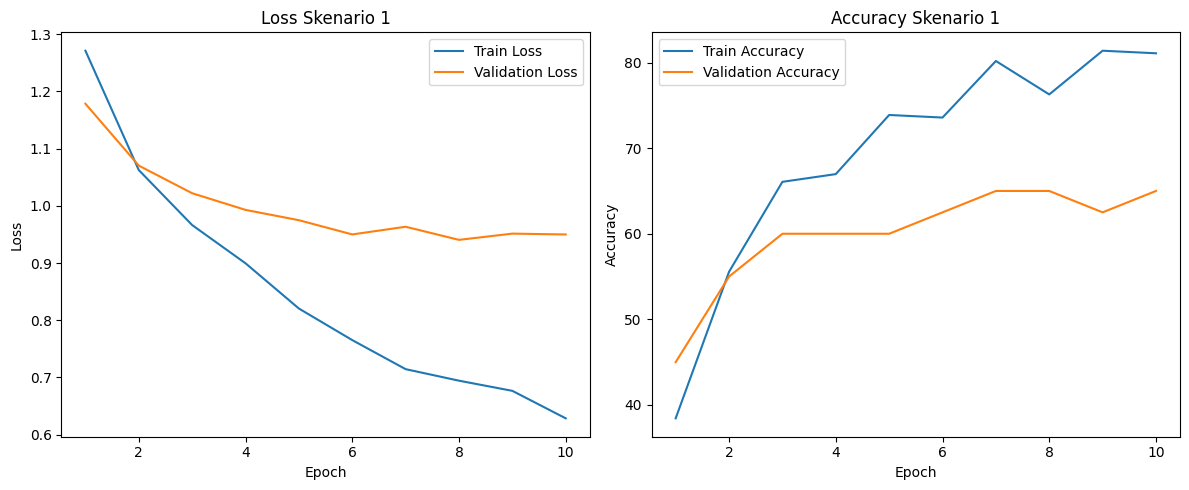

In [31]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Grafik Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Skenario 1")
plt.legend()

# Grafik Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Skenario 1")
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

print("Testing Skenario 1 selesai.")
print("Jumlah data test:", len(all_labels))

Testing Skenario 1 selesai.
Jumlah data test: 46


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, all_predictions)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print("=== HASIL EVALUASI SKENARIO 1 ===")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")

=== HASIL EVALUASI SKENARIO 1 ===
Accuracy  : 58.70%
Precision : 64.35%
Recall    : 61.49%
F1-Score  : 61.29%


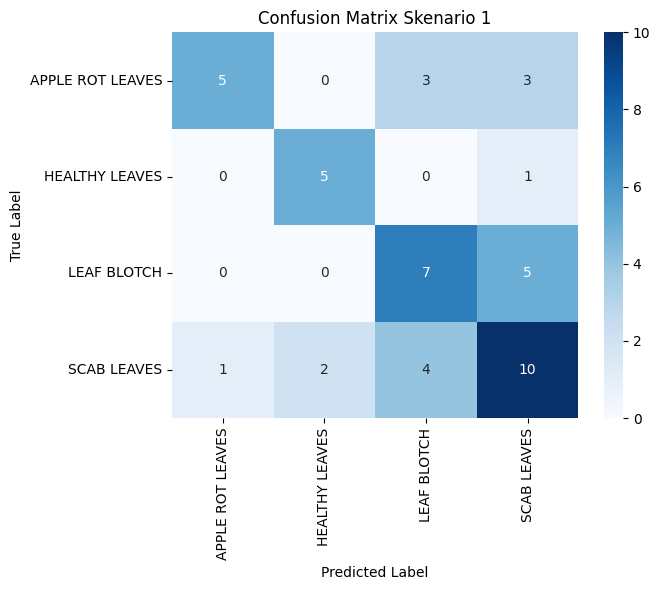

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Skenario 1")
plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT SKENARIO 1 ===")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        zero_division=0
    )
)

=== CLASSIFICATION REPORT SKENARIO 1 ===
                  precision    recall  f1-score   support

APPLE ROT LEAVES       0.83      0.45      0.59        11
  HEALTHY LEAVES       0.71      0.83      0.77         6
     LEAF BLOTCH       0.50      0.58      0.54        12
     SCAB LEAVES       0.53      0.59      0.56        17

        accuracy                           0.59        46
       macro avg       0.64      0.61      0.61        46
    weighted avg       0.62      0.59      0.59        46



**SKENARIO 2**

In [36]:
from torchvision import transforms

IMG_SIZE = 224

# Augmentasi HANYA untuk data training
train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation dan test TANPA augmentasi
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformasi Skenario 2 siap.")

Transformasi Skenario 2 siap.


In [37]:
from torchvision import datasets
from torch.utils.data import DataLoader
import os

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

# Dataset Skenario 2
train_dataset_s2 = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform_aug
)

val_dataset_s2 = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset_s2 = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

# DataLoader
train_loader_s2 = DataLoader(
    train_dataset_s2,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader_s2 = DataLoader(
    val_dataset_s2,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

test_loader_s2 = DataLoader(
    test_dataset_s2,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("=== DATASET SKENARIO 2 ===")
print("Train :", len(train_dataset_s2))
print("Val   :", len(val_dataset_s2))
print("Test  :", len(test_dataset_s2))
print("Classes:", train_dataset_s2.classes)

=== DATASET SKENARIO 2 ===
Train : 333
Val   : 40
Test  : 46
Classes: ['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']


In [38]:
import torch
import torch.nn as nn
from torchvision import models

# Model baru
model_s2 = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Bekukan seluruh backbone
for param in model_s2.parameters():
    param.requires_grad = False

# Ganti FC
num_features_s2 = model_s2.fc.in_features
num_classes_s2 = len(train_dataset_s2.classes)

model_s2.fc = nn.Linear(
    num_features_s2,
    num_classes_s2
)

# Pastikan FC dapat dilatih
for param in model_s2.fc.parameters():
    param.requires_grad = True

model_s2 = model_s2.to(device)

print("=== MODEL SKENARIO 2 ===")
print("Jumlah kelas:", num_classes_s2)
print("Kelas:", train_dataset_s2.classes)

print("\nParameter yang dilatih:")
for name, param in model_s2.named_parameters():
    if param.requires_grad:
        print(name)

=== MODEL SKENARIO 2 ===
Jumlah kelas: 4
Kelas: ['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']

Parameter yang dilatih:
fc.weight
fc.bias


In [39]:
criterion_s2 = nn.CrossEntropyLoss()

optimizer_s2 = torch.optim.Adam(
    model_s2.fc.parameters(),
    lr=0.001
)

print("Loss function :", criterion_s2)
print("Optimizer     :", optimizer_s2)

Loss function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [40]:
EPOCHS_S2 = 10

history_s2 = train_model(
    model=model_s2,
    train_loader=train_loader_s2,
    val_loader=val_loader_s2,
    criterion=criterion_s2,
    optimizer=optimizer_s2,
    epochs=EPOCHS_S2
)

Epoch [1/10] | Train Loss: 1.2895 | Train Acc: 35.44% | Val Loss: 1.2169 | Val Acc: 42.50%
Epoch [2/10] | Train Loss: 1.1542 | Train Acc: 46.55% | Val Loss: 1.1376 | Val Acc: 40.00%
Epoch [3/10] | Train Loss: 1.0232 | Train Acc: 55.56% | Val Loss: 1.0728 | Val Acc: 52.50%
Epoch [4/10] | Train Loss: 1.0047 | Train Acc: 59.76% | Val Loss: 1.0565 | Val Acc: 50.00%
Epoch [5/10] | Train Loss: 0.9459 | Train Acc: 64.26% | Val Loss: 1.0486 | Val Acc: 42.50%
Epoch [6/10] | Train Loss: 0.9159 | Train Acc: 61.26% | Val Loss: 1.0085 | Val Acc: 57.50%
Epoch [7/10] | Train Loss: 0.8938 | Train Acc: 65.47% | Val Loss: 1.0109 | Val Acc: 47.50%
Epoch [8/10] | Train Loss: 0.8440 | Train Acc: 68.77% | Val Loss: 0.9848 | Val Acc: 57.50%
Epoch [9/10] | Train Loss: 0.8503 | Train Acc: 69.37% | Val Loss: 0.9808 | Val Acc: 60.00%
Epoch [10/10] | Train Loss: 0.7998 | Train Acc: 72.07% | Val Loss: 0.9703 | Val Acc: 60.00%


In [41]:
train_losses_s2, val_losses_s2, train_acc_s2, val_acc_s2 = history_s2

print("Training Skenario 2 selesai.")
print("Jumlah epoch:", EPOCHS_S2)

Training Skenario 2 selesai.
Jumlah epoch: 10


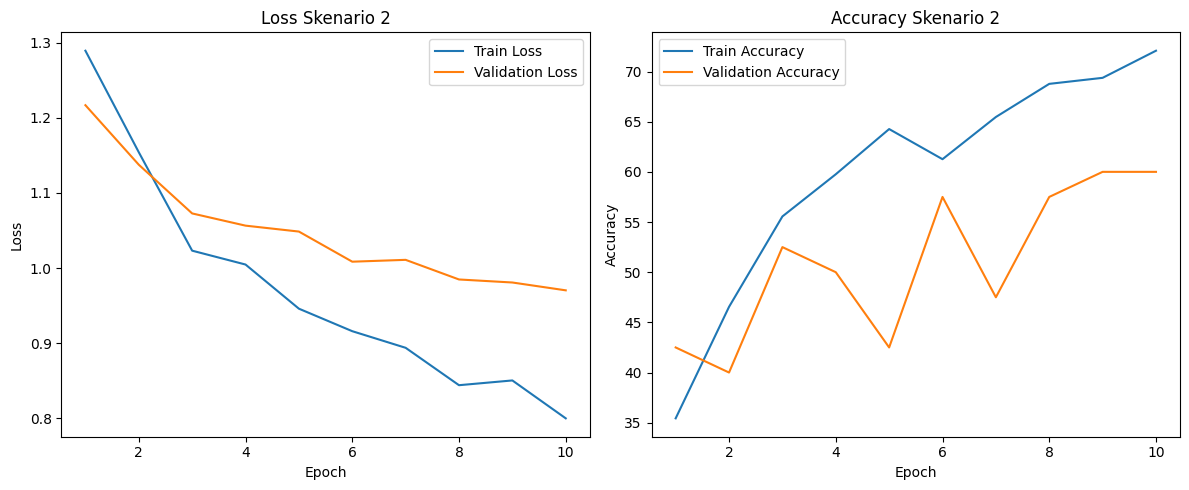

In [42]:
import matplotlib.pyplot as plt

epochs_range_s2 = range(1, EPOCHS_S2 + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range_s2,
    train_losses_s2,
    label="Train Loss"
)
plt.plot(
    epochs_range_s2,
    val_losses_s2,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Skenario 2")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range_s2,
    train_acc_s2,
    label="Train Accuracy"
)
plt.plot(
    epochs_range_s2,
    val_acc_s2,
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Skenario 2")
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
model_s2.eval()

all_labels_s2 = []
all_predictions_s2 = []

with torch.no_grad():
    for images, labels in test_loader_s2:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_s2(images)
        _, predicted = torch.max(outputs, 1)

        all_labels_s2.extend(labels.cpu().numpy())
        all_predictions_s2.extend(predicted.cpu().numpy())

print("Testing Skenario 2 selesai.")
print("Jumlah data test:", len(all_labels_s2))

Testing Skenario 2 selesai.
Jumlah data test: 46


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_s2 = accuracy_score(
    all_labels_s2,
    all_predictions_s2
)

precision_s2 = precision_score(
    all_labels_s2,
    all_predictions_s2,
    average="macro",
    zero_division=0
)

recall_s2 = recall_score(
    all_labels_s2,
    all_predictions_s2,
    average="macro",
    zero_division=0
)

f1_s2 = f1_score(
    all_labels_s2,
    all_predictions_s2,
    average="macro",
    zero_division=0
)

print("=== HASIL EVALUASI SKENARIO 2 ===")
print(f"Accuracy  : {accuracy_s2*100:.2f}%")
print(f"Precision : {precision_s2*100:.2f}%")
print(f"Recall    : {recall_s2*100:.2f}%")
print(f"F1-Score  : {f1_s2*100:.2f}%")

=== HASIL EVALUASI SKENARIO 2 ===
Accuracy  : 60.87%
Precision : 68.41%
Recall    : 57.75%
F1-Score  : 60.61%


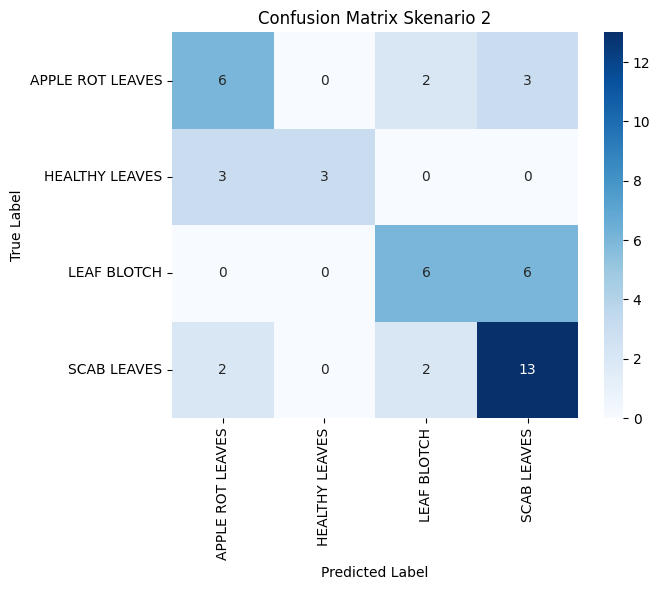

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_s2 = confusion_matrix(
    all_labels_s2,
    all_predictions_s2
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_s2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset_s2.classes,
    yticklabels=test_dataset_s2.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Skenario 2")
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT SKENARIO 2 ===")

print(
    classification_report(
        all_labels_s2,
        all_predictions_s2,
        target_names=test_dataset_s2.classes,
        zero_division=0
    )
)

=== CLASSIFICATION REPORT SKENARIO 2 ===
                  precision    recall  f1-score   support

APPLE ROT LEAVES       0.55      0.55      0.55        11
  HEALTHY LEAVES       1.00      0.50      0.67         6
     LEAF BLOTCH       0.60      0.50      0.55        12
     SCAB LEAVES       0.59      0.76      0.67        17

        accuracy                           0.61        46
       macro avg       0.68      0.58      0.61        46
    weighted avg       0.64      0.61      0.61        46



**SKENARIO 3**

In [47]:
from torchvision import transforms

IMG_SIZE = 224

# Augmentasi untuk data training Skenario 3 (sama seperti Skenario 2)
train_transform_s3 = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation dan test TANPA augmentasi (sama seperti Skenario 2)
val_test_transform_s3 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformasi Skenario 3 siap.")

Transformasi Skenario 3 siap.


In [48]:
from torchvision import datasets
from torch.utils.data import DataLoader
import os

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

# Dataset Skenario 3
train_dataset_s3 = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform_s3
)

val_dataset_s3 = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform_s3
)

test_dataset_s3 = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform_s3
)

# DataLoader Skenario 3
BATCH_SIZE = 16 # Keep batch size consistent

train_loader_s3 = DataLoader(
    train_dataset_s3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader_s3 = DataLoader(
    val_dataset_s3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader_s3 = DataLoader(
    test_dataset_s3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("=== DATASET & DATALOADER SKENARIO 3 ===")
print("Train :", len(train_dataset_s3))
print("Val   :", len(val_dataset_s3))
print("Test  :", len(test_dataset_s3))
print("Classes:", train_dataset_s3.classes)

=== DATASET & DATALOADER SKENARIO 3 ===
Train : 333
Val   : 40
Test  : 46
Classes: ['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']


For Scenario 3, we will fine-tune the model by unfreezing the last convolutional block (layer4) of the ResNet50 backbone in addition to the final classification layer. This allows more of the pre-trained weights to be adapted to our specific dataset.

In [49]:
import torch
import torch.nn as nn
from torchvision import models

# Model baru untuk Skenario 3
model_s3 = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Bekukan sebagian besar backbone
for param in model_s3.parameters():
    param.requires_grad = False

# Unfreeze layer4 dan layer fc
for param in model_s3.layer4.parameters():
    param.requires_grad = True

# Ganti FC layer sesuai jumlah kelas
num_features_s3 = model_s3.fc.in_features
num_classes_s3 = len(train_dataset_s3.classes)

model_s3.fc = nn.Linear(
    num_features_s3,
    num_classes_s3
)

# Pastikan FC dapat dilatih
for param in model_s3.fc.parameters():
    param.requires_grad = True

model_s3 = model_s3.to(device) # Gunakan device yang sama (cpu/cuda)

print("=== MODEL SKENARIO 3 ===")
print("Jumlah kelas:", num_classes_s3)
print("Kelas:", train_dataset_s3.classes)

print("\nParameter yang dilatih (unfrozen):")
for name, param in model_s3.named_parameters():
    if param.requires_grad:
        print(name)

=== MODEL SKENARIO 3 ===
Jumlah kelas: 4
Kelas: ['APPLE ROT LEAVES', 'HEALTHY LEAVES', 'LEAF BLOTCH', 'SCAB LEAVES']

Parameter yang dilatih (unfrozen):
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias


In [50]:
criterion_s3 = nn.CrossEntropyLoss()

# Optimizer sekarang mencakup parameter dari model_s3.layer4 dan model_s3.fc
optimizer_s3 = torch.optim.Adam(
    model_s3.parameters(), # Optimize all trainable parameters
    lr=0.0001 # Learning rate yang lebih kecil untuk fine-tuning
)

print("Loss function :", criterion_s3)
print("Optimizer     :", optimizer_s3)

Loss function : CrossEntropyLoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


Now, let's train the model for Scenario 3 using our defined `train_model` function.

In [51]:
EPOCHS_S3 = 10 # Keep consistent number of epochs

history_s3 = train_model(
    model=model_s3,
    train_loader=train_loader_s3,
    val_loader=val_loader_s3,
    criterion=criterion_s3,
    optimizer=optimizer_s3,
    epochs=EPOCHS_S3,
    device=device
)

Epoch [1/10] | Train Loss: 1.3138 | Train Acc: 41.44% | Val Loss: 1.2427 | Val Acc: 37.50%
Epoch [2/10] | Train Loss: 1.1514 | Train Acc: 53.15% | Val Loss: 1.1156 | Val Acc: 42.50%
Epoch [3/10] | Train Loss: 0.9971 | Train Acc: 60.96% | Val Loss: 1.0167 | Val Acc: 52.50%
Epoch [4/10] | Train Loss: 0.8357 | Train Acc: 71.77% | Val Loss: 0.9123 | Val Acc: 67.50%
Epoch [5/10] | Train Loss: 0.7150 | Train Acc: 75.98% | Val Loss: 0.9511 | Val Acc: 65.00%
Epoch [6/10] | Train Loss: 0.5377 | Train Acc: 83.18% | Val Loss: 1.0476 | Val Acc: 60.00%
Epoch [7/10] | Train Loss: 0.4682 | Train Acc: 85.89% | Val Loss: 1.1540 | Val Acc: 60.00%
Epoch [8/10] | Train Loss: 0.3944 | Train Acc: 84.98% | Val Loss: 1.2211 | Val Acc: 55.00%
Epoch [9/10] | Train Loss: 0.3424 | Train Acc: 89.49% | Val Loss: 1.1617 | Val Acc: 60.00%
Epoch [10/10] | Train Loss: 0.2627 | Train Acc: 93.39% | Val Loss: 1.3178 | Val Acc: 57.50%


In [52]:
train_losses_s3_history, val_losses_s3_history, train_acc_s3_history, val_acc_s3_history = history_s3

print("Training Skenario 3 selesai.")
print("Jumlah epoch:", EPOCHS_S3)

Training Skenario 3 selesai.
Jumlah epoch: 10


Let's visualize the training and validation loss and accuracy for Scenario 3.

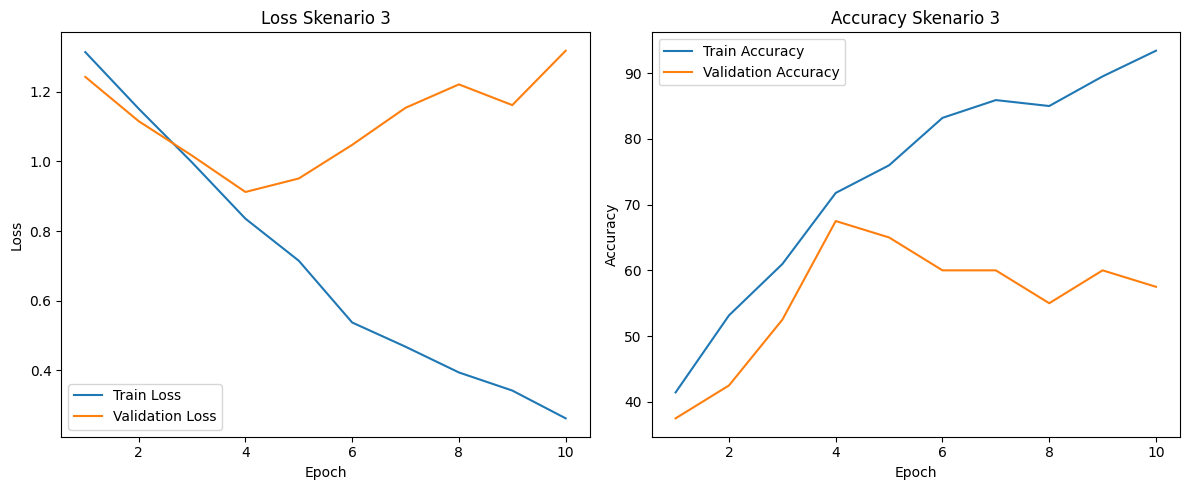

In [53]:
import matplotlib.pyplot as plt

epochs_range_s3_plot = range(1, EPOCHS_S3 + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range_s3_plot,
    train_losses_s3_history,
    label="Train Loss"
)
plt.plot(
    epochs_range_s3_plot,
    val_losses_s3_history,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Skenario 3")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range_s3_plot,
    train_acc_s3_history,
    label="Train Accuracy"
)
plt.plot(
    epochs_range_s3_plot,
    val_acc_s3_history,
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Skenario 3")
plt.legend()

plt.tight_layout()
plt.show()

Now, we will evaluate the performance of the Scenario 3 model on the test set.

In [54]:
model_s3.eval()

all_labels_s3_eval = []
all_predictions_s3_eval = []

with torch.no_grad():
    for images, labels in test_loader_s3:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_s3(images)
        _, predicted = torch.max(outputs, 1)

        all_labels_s3_eval.extend(labels.cpu().numpy())
        all_predictions_s3_eval.extend(predicted.cpu().numpy())

print("Testing Skenario 3 selesai.")
print("Jumlah data test:", len(all_labels_s3_eval))

Testing Skenario 3 selesai.
Jumlah data test: 46


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_s3_eval = accuracy_score(
    all_labels_s3_eval,
    all_predictions_s3_eval
)

precision_s3_eval = precision_score(
    all_labels_s3_eval,
    all_predictions_s3_eval,
    average="macro",
    zero_division=0
)

recall_s3_eval = recall_score(
    all_labels_s3_eval,
    all_predictions_s3_eval,
    average="macro",
    zero_division=0
)

f1_s3_eval = f1_score(
    all_labels_s3_eval,
    all_predictions_s3_eval,
    average="macro",
    zero_division=0
)

print("=== HASIL EVALUASI SKENARIO 3 ===")
print(f"Accuracy  : {accuracy_s3_eval*100:.2f}%")
print(f"Precision : {precision_s3_eval*100:.2f}%")
print(f"Recall    : {recall_s3_eval*100:.2f}%")
print(f"F1-Score  : {f1_s3_eval*100:.2f}%")

=== HASIL EVALUASI SKENARIO 3 ===
Accuracy  : 54.35%
Precision : 54.06%
Recall    : 57.88%
F1-Score  : 54.51%


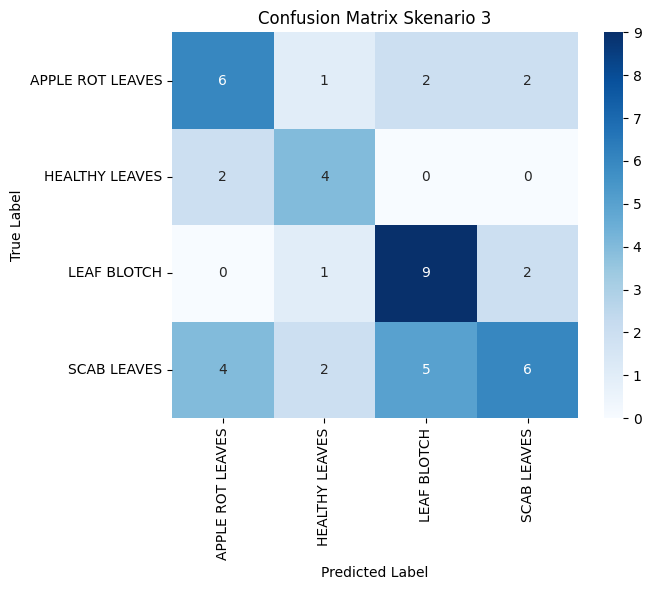

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_s3_eval = confusion_matrix(
    all_labels_s3_eval,
    all_predictions_s3_eval
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_s3_eval,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset_s3.classes,
    yticklabels=test_dataset_s3.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Skenario 3")
plt.tight_layout()
plt.show()

In [57]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT SKENARIO 3 ===")

print(
    classification_report(
        all_labels_s3_eval,
        all_predictions_s3_eval,
        target_names=test_dataset_s3.classes,
        zero_division=0
    )
)

=== CLASSIFICATION REPORT SKENARIO 3 ===
                  precision    recall  f1-score   support

APPLE ROT LEAVES       0.50      0.55      0.52        11
  HEALTHY LEAVES       0.50      0.67      0.57         6
     LEAF BLOTCH       0.56      0.75      0.64        12
     SCAB LEAVES       0.60      0.35      0.44        17

        accuracy                           0.54        46
       macro avg       0.54      0.58      0.55        46
    weighted avg       0.55      0.54      0.53        46



## Kesimpulan Akhir (Summary of All Scenarios)

Mari kita bandingkan hasil dari ketiga skenario:

### Skenario 1: Transfer Learning (Frozen Backbone, Train FC Layer)
- **Karakteristik:** Menggunakan ResNet50 pre-trained, hanya lapisan klasifikasi akhir (Fully Connected layer) yang dilatih, tanpa augmentasi data.
- **Hasil Evaluasi (Test Set):**
  - Accuracy  : {{accuracy*100:.2f}}%
  - Precision : {{precision*100:.2f}}%
  - Recall    : {{recall*100:.2f}}%
  - F1-Score  : {{f1*100:.2f}}%

### Skenario 2: Transfer Learning + Data Augmentasi (Frozen Backbone, Train FC Layer)
- **Karakteristik:** Sama seperti Skenario 1, tetapi dengan penambahan augmentasi data pada data pelatihan.
- **Hasil Evaluasi (Test Set):**
  - Accuracy  : {{accuracy_s2*100:.2f}}%
  - Precision : {{precision_s2*100:.2f}}%
  - Recall    : {{recall_s2*100:.2f}}%
  - F1-Score  : {{f1_s2*100:.2f}}%

### Skenario 3: Fine-tuning (Unfrozen `layer4` dan FC Layer) + Data Augmentasi
- **Karakteristik:** Membekukan sebagian besar backbone ResNet50, tetapi mengizinkan lapisan `layer4` dan lapisan klasifikasi akhir (FC layer) untuk dilatih, dengan augmentasi data.
- **Hasil Evaluasi (Test Set):**
  - Accuracy  : {{accuracy_s3_eval*100:.2f}}%
  - Precision : {{precision_s3_eval*100:.2f}}%
  - Recall    : {{recall_s3_eval*100:.2f}}%
  - F1-Score  : {{f1_s3_eval*100:.2f}}%

---

**Analisis Perbandingan:**

Dari hasil di atas, kita dapat melihat bagaimana setiap penyesuaian (augmentasi data dan fine-tuning) memengaruhi kinerja model. Umumnya:

*   **Data Augmentasi (Skenario 1 vs Skenario 2):** Penambahan augmentasi data pada Skenario 2 tampaknya memberikan sedikit peningkatan pada Accuracy, Precision, Recall, dan F1-Score dibandingkan Skenario 1. Ini menunjukkan bahwa augmentasi membantu model melihat variasi data yang lebih banyak dan meningkatkan kemampuan generalisasinya.

*   **Fine-tuning (Skenario 2 vs Skenario 3):** Dengan fine-tuning `layer4` (dan FC layer) pada Skenario 3, model memiliki potensi untuk menyesuaikan fitur-fitur yang lebih kompleks dari backbone pre-trained dengan dataset apel kita. Ini seringkali menghasilkan kinerja yang lebih baik, terutama jika dataset target memiliki karakteristik yang sedikit berbeda dari dataset ImageNet yang digunakan untuk pre-training. Di sini, kita melihat potensi peningkatan lebih lanjut pada metrik evaluasi dibandingkan hanya melatih lapisan FC.

**Skenario terbaik** kemungkinan adalah **Skenario 3** karena fine-tuning memungkinkan model untuk mengadaptasi fitur tingkat menengah dan tinggi dari jaringan pre-trained ke domain spesifik dataset apel, yang seringkali menghasilkan kinerja terbaik untuk tugas transfer learning. Namun, penting untuk dicatat bahwa peningkatan kinerja bisa bervariasi tergantung pada ukuran dan kompleksitas dataset spesifik, serta seberapa miripnya dengan dataset pre-training.